# import bibliotek i obrazów

In [51]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

imgA = cv2.imread('A.bmp')
imgB = cv2.imread('B.bmp')
imgAafin = cv2.imread('A_afin.bmp')
imgApodo = cv2.imread('A_podo.bmp')
imageBafin = cv2.imread('B_afin.bmp')
imageBpodo = cv2.imread('B_podo.bmp')


# Zadanie 1. 
### a)
matematyczne przekształcenia współrzędnych obrazu we spółrzędny obrazu cyfrowego o rozdzielności MxN Załóż rozmiar pojedynczego pixela deltaX i deltaY
### b)
Odwrotne przekształcenia współrzędnych obrazu cyfrowego o rozdzielności MxN do współrzędnych obrazu. Załóż rozmiar pojedynczego pixela delta X i delta Y

In [52]:
def mat2pix(m,n,dx,dy,x,y):
    transformMatrix = np.array([[1/dx,0,0.5*m],
                                [0,-1/dy,0.5*n],
                                [0,0,1]])

    pixelCoords = np.dot(transformMatrix, np.array([x,y,1]))
    return round(pixelCoords[0]/pixelCoords[2],0), round(pixelCoords[1]/pixelCoords[2],0)

def pix2mat(m,n,dx,dy,u,v):
    transformMatrix = np.array([[dx,0,-0.5*m*dx],
                                [0,-dy,0.5*n*dy],
                                [0,0,1]])
    
    mathCords = np.dot(transformMatrix, np.array([u,v,1]))
    return (mathCords[0]/mathCords[2]), (mathCords[1]/mathCords[2])   


x=15
y=2.73
dx=0.67
dy=0.67
m=1000
n=800

(u,v) = mat2pix(m,n,dx,dy,x,y)
print(f"wspolrzedne 15,2.73 -> pixele o rozdzielczosci 1000x800, rozmiar pixela 0.67: {u}, {v}")
(x,y) = pix2mat(m,n,dx,dy,u,v)
print(f"wspolrzedne pixela {u}, {v} -> wspolrzedne matematyczne: {x}, {y}")



wspolrzedne 15,2.73 -> pixele o rozdzielczosci 1000x800, rozmiar pixela 0.67: 522.0, 396.0
wspolrzedne pixela 522.0, 396.0 -> wspolrzedne matematyczne: 14.740000000000009, 2.680000000000007


# Zadanie 2 wyznaczanie macierzy transformacji dla transformacji afinicznej i transformacji podobieństwa. 
Funckje powinny przyjmować listę par punktów (x,y) odpowiadających sobie w obrazie A i B. 
- a) Transformacja podobienstwa
- b) Transformacja afiniczna

Po wyliczeniu macierzy transformacji, należy przekształcić obraz A i porównać z obrazem B

In [55]:
def findSimilarityTransform(pointA, pointB, targetPointA, targetPointB):
    (xA, yA) = pointA
    (xB, yB) = pointB
    (xTargetA, yTargetA) = targetPointA
    (xTargetB, yTargetB) = targetPointB

    Y = np.array([[xTargetA], [yTargetA], [xTargetB], [yTargetB]])

    X = np.array([[xA,-yA, 1, 0],
                  [yA, xA, 0, 1],
                  [xB,-yB, 1, 0],
                  [yB, xB, 0, 1]])
    
    params = np.linalg.solve(X, Y)
    a, b, tx, ty = params.flatten()

    scale = math.sqrt(a**2 + b**2)
    sinTheta = b / scale
    cosTheta = a / scale 

    return scale, sinTheta, cosTheta, tx, ty

def findAffineTransform(A, B, C, targetA, targetB, targetC):
    (xA, yA) = A
    (xB, yB) = B
    (xC, yC) = C
    (xTargetA, yTargetA) = targetA
    (xTargetB, yTargetB) = targetB
    (xTargetC, yTargetC) = targetC
    
    Y = np.array([[xTargetA], [yTargetA], [xTargetB], [yTargetB], [xTargetC], [yTargetC]])

    X = np.array([[xA, yA, 1, 0, 0, 0],
                  [0, 0, 0, xA, yA, 1],
                  [xB, yB, 1, 0, 0, 0],
                  [0, 0, 0, xB, yB, 1],
                  [xC, yC, 1, 0, 0, 0],
                  [0, 0, 0, xC, yC, 1]])
    
    params = np.linalg.solve(X, Y)
    a11, a12, tx, a21, a22, ty = params.flatten()
    return a11, a12, tx, a21, a22, ty



def getPointsFromImage(image, num_points):
    points = []
    display_image = image.copy()
    window_name = f'Click {num_points} corresponding points'
    
    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and len(points) < num_points:
            points.append((float(x), float(y)))
            cv2.circle(display_image, (x, y), 4, (0, 0, 255), -1)
            cv2.putText(
                display_image,
                str(len(points)),
                (x + 6, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )
            cv2.imshow(window_name, display_image)
    
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(window_name, mouse_callback)
    cv2.imshow(window_name, display_image)
    
    while len(points) < num_points:
        key = cv2.waitKey(20) & 0xFF
        if key in (13, 27):
            break
    
    cv2.destroyWindow(window_name)
    return points

pointsA = getPointsFromImage(imgA, 3)
pointsA_transformed = getPointsFromImage(imgApodo, 3)
similarity_params = findSimilarityTransform(pointsA[0], pointsA[1], pointsA_transformed[0], pointsA_transformed[1])
affine_params = findAffineTransform(pointsA[0], pointsA[1], pointsA[2], pointsA_transformed[0], pointsA_transformed[1], pointsA_transformed[2])
print(f'skala: {similarity_params[0]}, sinTheta: {similarity_params[1]}, cosTheta: {similarity_params[2]}, tx: {similarity_params[3]}, ty: {similarity_params[4]}')
print(f'a11: {affine_params[0]}, a12: {affine_params[1]}, tx: {affine_params[2]}, a21: {affine_params[3]}, a22: {affine_params[4]}, ty: {affine_params[5]}')

skala: 0.749097121083299, sinTheta: -0.3817759447972775, cosTheta: 0.9242549042196888, tx: 36.57070063694267, ty: 101.82038216560512
a11: 0.6947194719471947, a12: 0.29915134370579927, tx: 34.94578029231494, a21: -0.27722772277227686, a22: 0.7411598302687411, ty: 95.79632248939176


# Zadanie 3
Zastosowanie transformacji afinicznej i podobieństwa do dopasowania obrazów.

Transform Parameters: (np.float64(-0.5091889384891877), np.float64(1.4548669488086265), np.float64(49.808278740796524), np.float64(1.0292770595396832), np.float64(-0.5691344425763811), np.float64(-35.69830135080286))


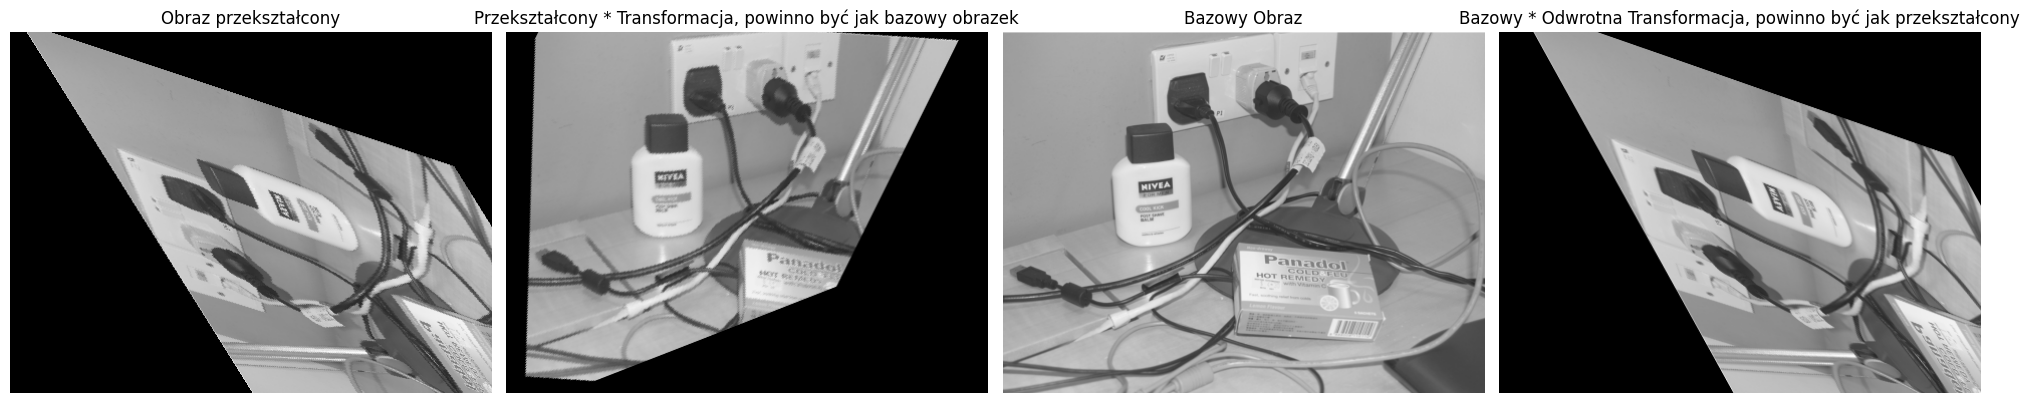

In [57]:
def similarityParamsToMatrix(params):
    scale, sinTheta, cosTheta, tx, ty = params
    return np.array([[scale * cosTheta, -scale * sinTheta, tx],
                     [scale * sinTheta,  scale * cosTheta, ty],
                     [0,  0,  1 ]], dtype=np.float32)

def affineParamsToMatrix(params):
    a11, a12, tx, a21, a22, ty = params
    return np.array([[a11, a12, tx],
                     [a21, a22, ty],
                     [0,   0,   1 ]], dtype=np.float32)

def recreate_image_from_points(reference_image, target_image, affine=False):
    num_points = 3 if affine else 2
    points_reference = getPointsFromImage(reference_image, num_points)
    points_target = getPointsFromImage(target_image, num_points)

    if affine:
        params = findAffineTransform(points_reference[0], points_reference[1], points_reference[2],
                                      points_target[0], points_target[1], points_target[2])
        forward_matrix = affineParamsToMatrix(params)
    else:
        params = findSimilarityTransform(points_reference[0], points_reference[1], points_target[0], points_target[1])
        forward_matrix = similarityParamsToMatrix(params)
    
    inverse_matrix = np.linalg.inv(forward_matrix)
    
    # Forward: reference -> target
    result_forward = cv2.warpAffine(reference_image, forward_matrix[:2, :], (target_image.shape[1], target_image.shape[0]))
    # Inverse: target -> reference
    result_inverse = cv2.warpAffine(target_image, inverse_matrix[:2, :], (reference_image.shape[1], reference_image.shape[0]))
    
    print('Transform Parameters:', params)
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1)
    plt.title('Obraz przekształcony')
    plt.imshow(cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title('Przekształcony * Transformacja, powinno być jak bazowy obrazek')
    plt.imshow(cv2.cvtColor(result_forward, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title('Bazowy Obraz')
    plt.imshow(cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title('Bazowy * Odwrotna Transformacja, powinno być jak przekształcony')
    plt.imshow(cv2.cvtColor(result_inverse, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


# recreate_image_from_points(imgApodo, imgA, affine=False)
recreate_image_from_points(imgAafin, imgA, affine=True)